In [1]:
import stan
import pandas as pd
import pickle

import nest_asyncio
nest_asyncio.apply()

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import optimize
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy.stats import nbinom
from scipy.stats import norm
from scipy.special import logit
import arviz as az

from datetime import datetime
from meteostat import Stations, Point, Daily

%matplotlib inline

# Load in and clean data

## Clean and pickle OxCGRT data

In [2]:
# Last updated data: 2024-05-13

In [3]:
# Oxford CGRT data
cgrt_data = pd.read_csv('https://raw.githubusercontent.com/OxCGRT/covid-policy-tracker/master/data/United%20States/OxCGRT_USA_latest.csv')
data = cgrt_data[cgrt_data['CountryCode']=="USA"]
states = pd.unique(data['RegionName'])[1:]

In [4]:
# convert to numeric with half step for targeted/partial measures, per OxCGRT codebook
data['School closure'] = data['C1M_School closing'] - 0.5*(1-np.isnan(data['C1M_Flag']))*(1-data['C1M_Flag'])
data['Workplace closure'] = data['C2M_Workplace closing'] - 0.5*(1-np.isnan(data['C2M_Flag']))*(1-data['C2M_Flag'])
data['Cancel public events'] = data['C3M_Cancel public events'] - 0.5*(1-np.isnan(data['C3M_Flag']))*(1-data['C3M_Flag'])
data['Restrictions on gatherings'] = data['C4M_Restrictions on gatherings'] - 0.5*(1-np.isnan(data['C4M_Flag']))*(1-data['C4M_Flag'])
data['Public transport closure'] = data['C5M_Close public transport'] - 0.5*(1-np.isnan(data['C5M_Flag']))*(1-data['C5M_Flag'])
data['Stay at home requirements'] = data['C6M_Stay at home requirements'] - 0.5*(1-np.isnan(data['C6M_Flag']))*(1-data['C6M_Flag'])
data['Restrictions on internal movement'] = data['C7M_Restrictions on internal movement'] - 0.5*(1-np.isnan(data['C7M_Flag']))*(1-data['C7M_Flag'])
data['Public information campaigns'] = data['H1_Public information campaigns'] - 0.5*(1-np.isnan(data['H1_Flag']))*(1-data['H1_Flag'])
data['Testing policy'] = data['H2_Testing policy']
data['Contact tracing'] = data['H3_Contact tracing']
data['Facial coverings'] = data['H6M_Facial Coverings'] - 0.5*(1-np.isnan(data['H6M_Flag']))*(1-data['H6M_Flag'])

In [5]:
data.to_pickle('oxcgrt_data_20240513.pkl')

## Load data

In [6]:
# oxford CGRT data
data = pd.read_pickle('oxcgrt_data_20240513.pkl')
states = pd.unique(data['RegionName'])[1:]

# US state data: population counts; largest city lat-lon coords; name abbreviations
pops = pd.read_pickle('state_populations_2020.pkl')
state_coords = pd.read_pickle('state_city_coords.pkl')
state_abbrev = pd.read_pickle('state_abbrev_20230518.pkl')

# IFR estimates from Irons and Raftery (2021)
state_ifr = pd.read_pickle('state_ifr.pkl')

In [7]:
# functions to extract and clean NPI, case, death, and temperature data

def get_state_data(data,state):
    state_data = data[data['RegionName']==state]
    return state_data

def get_state_pop(pops, state):
    state_tmp = state
    if state == 'Washington DC':
        state_tmp = 'District of Columbia'
        
    N = pops[pops['State']==state_tmp]['Population']
    N = np.array(N).astype('float')
    return N

def clean_npis(state_data,tf,npis):
    u = state_data[npis]
    u = np.array(u)[0:tf,:].astype(float);
    p = np.shape(u)[1]
    
    # set NaN values to last number previously recorded
    for j in range(tf):
        # determine columns with NaN values
        nancols = np.isnan(u[j,:])
        if j == 0:
            # on day 0, change any NaN to 0, meaning that no policies are enacted
            u[j,nancols] = 0
        else:
            # set any NaN to last recorded value
            u[j,nancols] = u[j-1,nancols]
     
    # normalize policy values to lie between 0 and 1
    for j in range(p):
        if sum(u[:,j]>0)>0:
            u[:,j] = u[:,j]/np.nanmax(u[:,j], )
    return u, p

def clean_deaths(state_data,tf):
    # get confirmed deaths
    d = np.array(state_data['ConfirmedDeaths'])[0:tf].astype(float)
    d[np.isnan(d)] = 0
    
    # alter cumulative death counts to make them non-decreasing in time
    for j in range(tf-1,-1,-1):
        d[j] = np.min(d[j:tf])
    
    # calculate death count on each day
    d = np.append(0,np.diff(d))
    return d

def clean_cases(state_data,tf):
    # get confirmed cases
    d = np.array(state_data['ConfirmedCases'])[0:tf].astype(float)
    d[np.isnan(d)] = 0
    
    # alter cumulative case counts to make them non-decreasing in time
    for j in range(tf-1,-1,-1):
        d[j] = np.min(d[j:tf])
    
    # calculate case count on each day
    d = np.append(0,np.diff(d))
    return d

def get_dates(state_data,tf):
    return np.array(state_data['Date'])[0:tf]

def get_state_temp(state_coords,state,start,end):
    state_tmp = state
    if state == 'Washington DC':
        state_tmp = 'District of Columbia'
    
    state_latlon = state_coords[state_coords['State']==state_tmp].iloc[0]
    
    station = Point(
        lat = state_latlon['Latitude'], 
        lon = state_latlon['Longitude'],
    )
    station.method = 'weighted'
    
    temp_data = Daily(station, start, end)
    temp_data = temp_data.fetch()
    return temp_data['tavg'].interpolate()

In [8]:
# NPIs in model
npis = [
    'School closure',
    'Workplace closure',
    'Cancel public events',
    'Restrictions on gatherings',
    'Public transport closure',
    'Stay at home requirements',
    'Restrictions on internal movement',
    'Public information campaigns',
    'Testing policy',
    'Contact tracing',
    'Facial coverings'
]

# Clean and extract NPI, case, death, and temperature data

In [12]:
# define time-to-death distribution tau
death_cutoff = 40
tau_rev = np.flip(norm.pdf(np.arange(0,death_cutoff+1), 21, 5))
tau_rev = tau_rev/np.sum(tau_rev)

In [13]:
t = 366 # number of in-sample days to model, 366 in 2020
tf = t+10 # final time for data extraction

num_states = 51 #number of states to model

starts = np.zeros(num_states)
n = np.zeros(num_states)
days_pred = np.zeros(num_states)
days = np.zeros(num_states)
npis = [
    'School closure',
    'Workplace closure',
    'Cancel public events',
    'Restrictions on gatherings',
    'Public transport closure',
    'Stay at home requirements',
    'Restrictions on internal movement',
    'Public information campaigns',
    'Testing policy',
    'Contact tracing',
    'Facial coverings'
]    

states_to_model = states[0:num_states]

d0 = np.zeros(num_states)
c0 = np.zeros(num_states)
death_cutoffs = np.zeros(num_states)
npi_cutoffs = np.zeros(num_states)
for count,state in enumerate(states_to_model):
    
    n_tmp = get_state_pop(pops,state)
    n[count] = n_tmp
    
    state_data = get_state_data(data,state)
    u_tmp, p = clean_npis(state_data,tf,npis)
    d_tmp = clean_deaths(state_data,tf)
    c_tmp = clean_cases(state_data,tf)
    dates_tmp = get_dates(state_data,tf)
    
    # start modeling 21 days before the first day on which more than 1 death is reported
    death_start = np.min(np.where(d_tmp > 1)) - 21
    npi_start = np.min(np.where(np.mean(u_tmp,axis=1) > 0))
    start = np.max((death_start,0))
    
    death_cutoffs[count] = death_start - start;
     
    npi_cutoffs[count] = 30;
    
    starts[count] = start
    days[count] = t-start
    d0[count] = np.sum(d_tmp[0:start])
    c0[count] = np.sum(c_tmp[0:start])
    
    end_date_tmp = datetime.strptime(str(dates_tmp[t]),'%Y%m%d')
    tavg_tmp = get_state_temp(state_coords,state,datetime(2020,1,1),end_date_tmp)
    
    if count == 0:  
        u = u_tmp[start:t,]
        dates = dates_tmp[start:t]
            
        d = d_tmp[start:t]
        c = c_tmp[start:t]   
        
        tavg = tavg_tmp[start:t]
        tavg_dates = tavg_tmp.index[start:t]
        
        d_full = d_tmp[start:t]
        c_full = c_tmp[start:t]
    else:
        u = np.concatenate([u,u_tmp[start:t,]])
        dates = np.concatenate([dates,dates_tmp[start:t]])
            
        dtmp = d_tmp[start:t]
        ctmp = c_tmp[start:t]
    
        tavgtmp = tavg_tmp[start:t]
        tavgtmp_dates = tavg_tmp.index[start:t]
        d = np.concatenate([d,dtmp])
        c = np.concatenate([c,ctmp])
        tavg = np.concatenate([tavg,tavgtmp])
        tavg_dates = np.concatenate([tavg_dates,tavgtmp_dates])
        
        d_full = np.concatenate([d_full,d_tmp[start:t]])
        c_full = np.concatenate([c_full,c_tmp[start:t]])

In [14]:
ttotal = np.shape(d)[0]
s = num_states
n_compartments = 5
t_npi = np.cumsum(np.concatenate([np.array([0]),days])).astype(int)
t_d = np.cumsum(np.concatenate([np.array([0]),days])).astype(int)

### Some data viz

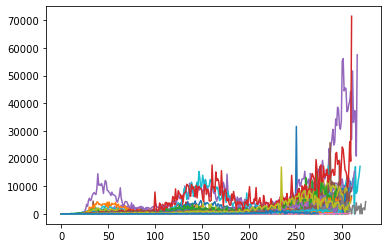

In [15]:
# cases
for j in range(num_states):
    plt.plot(c[t_d[j]:t_d[j+1]])

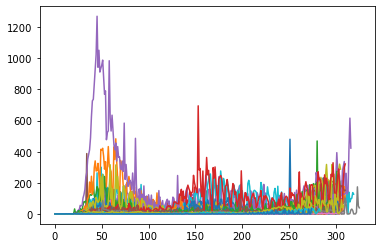

In [16]:
# deaths
for j in range(num_states):
    plt.plot(d[t_d[j]:t_d[j+1]])

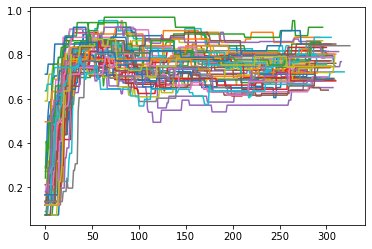

In [17]:
# npis
for j in range(num_states):
    plt.plot(np.mean(u[t_npi[j]:t_npi[j+1],],axis=1))

## Setting up weekly error term structure

In [18]:
from datetime import datetime as dt
from datetime import date

In [19]:
# weekly error terms
error_term_inds = np.zeros(t_npi[s])

for n_state in range(s):
    error_term_inds_state = np.ones(t_npi[n_state+1]-t_npi[n_state])   
    
    for day in range(t_npi[n_state+1]-t_npi[n_state]):
        if day > 0:
            is_sunday = (dt.strptime(str(dates[t_npi[n_state]+day]),'%Y%m%d').weekday() == 6)
            if is_sunday:
                error_term_inds_state[day] = error_term_inds_state[day-1]+1
            else: 
                error_term_inds_state[day] = error_term_inds_state[day-1]
    
    error_term_inds[t_npi[n_state]:t_npi[n_state+1]] = np.max(error_term_inds) + error_term_inds_state

## Set up the data as JSON for R

In [20]:
init_dict = {"beta0_s": 0.6 * np.ones(s), 
             "beta_eps": np.zeros(ttotal), 
             "gamma": 0.18 * np.ones(s),
             "delta": 0.2 * np.ones(s),
             "mu_r": 0.1 * np.ones(s), 
             'tau':0.25 *np.ones(s),
             'rr':0.03*np.ones(s),
             'car0':0.01*np.ones(s),
             'car_delta':0.01*np.ones(s),
             'car_sigma':0.2*np.ones(s),
             'car_eps':np.zeros(ttotal),
             "rho": np.zeros(p), 
             "sigma": np.ones(s),
             "kappa" : np.ones(s)/100,
             "kappa_c" : np.ones(s)/100,
             "x0" : np.ones([s,n_compartments])/n_compartments
             }

In [21]:
# set parameters

init_prop = 0.01
u_fit = u
p = u_fit.shape[1]

s = num_states
n_compartments = 5
t_model = t_d
    
# weekly/monthly error terms
error_term_inds_final = error_term_inds.astype(int)   
    
# calculate days of non-zero deaths for zero-inflated model
d_nz = (d>0)
d_z = (d==0)
d_nz_inds = np.where(d_nz)[0]+1
d_z_inds = np.where(d_z)[0]+1
n0_d = np.zeros(s)
nz_d = np.zeros(s)
for state in range(s):
    n0_d[state] = np.sum(d_z[t_d[state]:t_d[state+1]])
    nz_d[state] = np.sum(d_nz[t_d[state]:t_d[state+1]])
    
d_model = np.array(d)
d_model[np.isnan(d)] = 0
n0_d_cumsum = np.cumsum(np.concatenate((np.zeros(1),n0_d))).astype(int)
nz_d_cumsum = np.cumsum(np.concatenate((np.zeros(1),nz_d))).astype(int)

# calculate days of non-zero cases for zero-inflated model
c_nz = (c>0)
c_z = (c==0)
c_nz_inds = np.where(c_nz)[0]+1
c_z_inds = np.where(c_z)[0]+1
n0_c = np.zeros(s)
nz_c = np.zeros(s)
for state in range(s):
    n0_c[state] = np.sum(c_z[t_d[state]:t_d[state+1]])
    nz_c[state] = np.sum(c_nz[t_d[state]:t_d[state+1]])
    
c_model = np.array(c)
c_model[np.isnan(c)] = 0
n0_c_cumsum = np.cumsum(np.concatenate((np.zeros(1),n0_c))).astype(int)
nz_c_cumsum = np.cumsum(np.concatenate((np.zeros(1),nz_c))).astype(int)

d_full = np.array(d_full)
d_full[np.isnan(d_full)] = 0
c_full = np.array(c_full)
c_full[np.isnan(c_full)] = 0
    
# state inds for death days
state_inds = np.zeros(t_d[s])
state_inds_full = np.zeros(t_npi[s])
for state in range(s):
    for day in range(t_d[state],t_d[state+1]):
        state_inds[day] = state+1
    for day in range(t_npi[state],t_npi[state+1]):
        state_inds_full[day] = state+1    
        
# state-level IFRs
model_ifr = state_ifr.loc[state_ifr['name'].isin(states_to_model)]
ifr_upper = np.zeros(s); ifr_lower = np.zeros(s); ifr_mean = np.zeros(s);
for state in range(s):
    ifr_upper[state] = model_ifr.loc[model_ifr['name'] == states_to_model[state]]['ifr_upper']
    ifr_lower[state] = model_ifr.loc[model_ifr['name'] == states_to_model[state]]['ifr_lower']
    ifr_mean[state] = model_ifr.loc[model_ifr['name'] == states_to_model[state]]['ifr_mean'] 
ifr_sd = (ifr_upper-ifr_lower)/4

# state abbreviations
abbrev = []
for state in range(s):
     abbrev.append(state_abbrev.loc[state_abbrev['state'] == states_to_model[state]]['abbreviation'].values[0])

init_props = init_prop*np.ones(s)

sigma_upper = 1;
sigma_mean = 0.05/sigma_upper;
sigma_var = (0.025/sigma_upper)**2;
alpha_sigma = sigma_mean*(sigma_mean*(1-sigma_mean)-sigma_var)/sigma_var;
beta_sigma = alpha_sigma*(1-sigma_mean)/sigma_mean;

stan_data = {'n0_d': n0_d.astype(int), 'nz_d' : nz_d.astype(int),
             'd_nz_inds' : d_nz_inds.astype(int), 'd_z_inds' : d_z_inds.astype(int),   
             'd_nz_len' : d_nz_inds.shape[0], 'd_z_len' : d_z_inds.shape[0], 
             'n0_d_cumsum': n0_d_cumsum, 'nz_d_cumsum': nz_d_cumsum,
             'n0_c': n0_c.astype(int), 'nz_c' : nz_c.astype(int),
             'c_nz_inds' : c_nz_inds.astype(int), 'c_z_inds' : c_z_inds.astype(int),   
             'c_nz_len' : c_nz_inds.shape[0], 'c_z_len' : c_z_inds.shape[0], 
             'n0_c_cumsum': n0_c_cumsum, 'nz_c_cumsum': nz_c_cumsum,
             'tavg' : tavg, 'state_inds' : state_inds.astype(int),
    "p" : p, "s" : s, "t" : t_model, "t_d" : t_d, "n_d" : days.astype(int), 
                "d" : d_model.astype(int), 'c' : c_model.astype(int), "u" : u_fit,
             "n" : n.astype(int), "tau_rev" : tau_rev, 
            "n_compartments" : n_compartments, 'ifr': 0.0068, 
                'd0':d0.astype(int), 'c0':c0.astype(int),
            "delta": 1/7, "gamma": 1/7, "mu": 1/14, 'init_prop':init_prop,
             'tau_upper' : 30, 'tau_mean' : 10, 'tau_sd' : 5, 'tau_lower': 1,
             'gamma_upper' : 11.5, 'gamma_mean' : 8.5, 'gamma_sd' : 1.5, 'gamma_lower': 5.5, 
             'delta_upper' : 6, 'delta_mean' : 5.1, 'delta_sd' : 0.35, 'delta_lower': 4, 
             'mu_upper' : 16, 'mu_mean' : 10, 'mu_sd' : 3, 'mu_lower': 4, 
             'r0_upper' : 3.28+3*1.16/1.34896, 'r0_mean' : 3.28, 'r0_sd' : 1.16/1.34896, 
             'r0_lower': 3.28-3*1.16/1.34896, 'r0_median' : 2.79, 
             'ifr_upper': ifr_upper/100, 'ifr_lower': ifr_lower/100, 
             'ifr_mean': ifr_mean/100, 'ifr_sd': ifr_sd/100, 'ifr':ifr_mean/100,
             'error_term_inds': error_term_inds_final, 
             'n_error_terms': np.max(error_term_inds_final).astype(int),
             'muI_upper': 30, 'muI_lower':2, 'muI_mean': 8.5 + 10, 'muI_sd': np.sqrt(3 + 1.5),
             'qq_upper': 0.25, 'qq_lower': 0, 'qq_mean': 0.1, 'qq_sd': 0.05,
             'sigma_upper' : sigma_upper, 'alpha_sigma':alpha_sigma, 'beta_sigma':beta_sigma,
             'kappa_d_upper': 1000, 'kappa_c_upper': 100, 
             'npi_cutoffs':npi_cutoffs.astype(int), 'death_cutoffs':death_cutoffs.astype(int),
             'init_props': init_props,
             'd_full': d_full.astype(int), 'c_full': c_full.astype(int),
             'state_inds_full':state_inds_full.astype(int),
           }

model_data = {'npis': npis, 'dates': dates, 'states': states_to_model, 'tavg_dates':tavg_dates,'abbrev': abbrev
             }

In [22]:
import json

stan_data_json = {}

# loop over dictionary keys and values
for key, val in stan_data.items():
    
    if type(stan_data[key]) == np.ndarray:
        stan_data_json[key] = val.tolist()
    elif type(stan_data[key]) == np.int64:
        stan_data_json[key] = int(val)
    else:
        stan_data_json[key] = val

with open('stan_data.json', "w") as fp:
    json.dump(stan_data_json,fp) 

In [23]:
import json

model_data_json = {}

# loop over dictionary keys and values
for key, val in model_data.items():
    
    if type(model_data[key]) == np.ndarray:
        model_data_json[key] = val.tolist()
    elif type(model_data[key]) == np.int64:
        model_data_json[key] = int(val)
    else:
        model_data_json[key] = val

with open('model_data.json', "w") as fp:
    json.dump(model_data_json,fp) 